In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.metrics.pairwise import linear_kernel,cosine_similarity
from ast import literal_eval
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Looking at starting rows of both dataframes to get idea what we are dealing with

---

In [2]:
df1 = pd.read_csv('tmdb_5000_credits.csv')
df2 = pd.read_csv('tmdb_5000_movies.csv')
df1.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


---

In [3]:
df2.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


## Merging both datasets to one to combine everything into one main DataFrame using 'id' feature

---


> Let's join the two datasets on the 'id' column


In [4]:
df1.columns = ['id','title_x','cast','crew']
df2 = df2.merge(df1,on = 'id')
df2.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,title_x,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


---

In [5]:
m = df2['vote_count'].quantile(0.9)
C = df2['vote_average'].mean()

 ## Defining IMDB Formula for calculating score of each movie

---

In [6]:
def weight_average(x):
    v = x['vote_count']
    R = x['vote_average']
    return (v/(v+m))*R + (m/(v+m))*C

 ## Filtering Dataframe to get movies with vote count >= m (minimum votes required to appear on chart)

---

In [7]:
q_movies = df2.copy().loc[df2['vote_count'] >= m]
q_movies.shape

(481, 23)

 ## Adding new feature 'score' according to IMDB formula to rank these movies rating wise

---

In [8]:
q_movies['score'] = q_movies.apply(weight_average , axis = 1)
q_movies.shape

(481, 24)

 ## Sorting According to 'Score' attribute and find top 10 IMDB rated movies

---

In [9]:
q_movies = q_movies.sort_values('score' , ascending = False)
q_movies[['title','score','vote_average','vote_count']].head(10)

,title,score,vote_average,vote_count
1881,The Shawshank Redemption,8.059258,8.5,8205
662,Fight Club,7.939256,8.3,9413
65,The Dark Knight,7.920020,8.2,12002
3232,Pulp Fiction,7.904645,8.3,8428
96,Inception,7.863239,8.1,13752
3337,The Godfather,7.851236,8.4,5893
95,Interstellar,7.809479,8.1,10867
809,Forrest Gump,7.803188,8.2,7927
329,The Lord of the Rings: The Return of the King,7.727243,8.1,8064
1990,The Empire Strikes Back,7.697884,8.2,5879


## To see top trending movies according to our given data we can sort these movies on popularity attribute

---

Text(0.5, 1.0, 'Popular Movies')

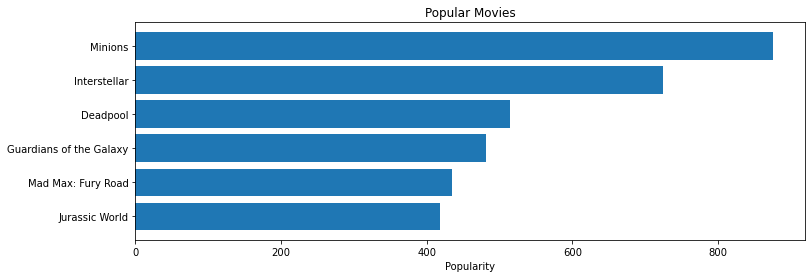

In [10]:
pop = df2.sort_values('popularity' , ascending = False)
plt.figure(figsize=(12,4))
plt.barh(pop['title'].head(6),pop['popularity'].head(6))
plt.gca().invert_yaxis()
plt.xlabel("Popularity")
plt.title("Popular Movies")

## Initializing TDF-IDF vectorizer object to generate TDF-IDF matrix of plots of movies

---

In [11]:
tfidf = TfidfVectorizer( stop_words='english' )
df2['overview'] = df2['overview'].fillna('')
tfidf_matrix = tfidf.fit_transform(df2['overview'])
tfidf_matrix.shape

(4803, 20978)

In [12]:
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
cosine_sim.shape

(4803, 4803)

## Now to get recommendations one will input the movie title and our recommender will generate top 10 movies similar to the input movie based on similar plots or stories

---

In [13]:
indices = pd.Series(df2.index, index=df2['title']).drop_duplicates()
def get_recommendations(title,cosine_sim = cosine_sim):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return df2['title'].iloc[movie_indices]

## Testing our recommender System

---

In [14]:
get_recommendations('The Dark Knight Rises')

65                              The Dark Knight
299                              Batman Forever
428                              Batman Returns
1359                                     Batman
3854    Batman: The Dark Knight Returns, Part 2
119                               Batman Begins
2507                                  Slow Burn
9            Batman v Superman: Dawn of Justice
1181                                        JFK
210                              Batman & Robin
Name: title, dtype: object

In [15]:
get_recommendations('The Godfather')

2731     The Godfather: Part II
1873                 Blood Ties
867     The Godfather: Part III
3727                 Easy Money
3623                       Made
3125                     Eulogy
3896                   Sinister
4506            The Maid's Room
3783                        Joe
2244      The Cold Light of Day
Name: title, dtype: object

### Our dataset contains values of credits, genres or keywords in the form of strings and not python objects like lists or dictionaries, so to convert them to python objects we use builtin function

In [16]:
features = ['cast', 'crew', 'keywords', 'genres']
for feature in features:
    df2[feature] = df2[feature].apply(literal_eval)

## Function to get director's name of respective movies

---

In [17]:
def get_director(x):
    for i in x:
        if (i['job'] == 'Director'):
            return i['name']
    return np.nan

## Fuction to get list of 3 elements for each feature

---

In [18]:
def get_list(x):
    if (isinstance(x,list)):
        names = [i['name'] for i in x]
        if len(names) > 3:
            return names[:3]
        return names
    return []

## Redefining our features as per functions we made

---

In [19]:
df2['director'] = df2['crew'].apply(get_director)
features = ['cast', 'keywords', 'genres']
for feature in features:
    df2[feature] = df2[feature].apply(get_list)

## Peeking at our modified dataset

---

In [20]:
df2[['title', 'cast', 'director', 'keywords', 'genres']].head(5)

,title,cast,director,keywords,genres
0,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",James Cameron,"[culture clash, future, space war]","[Action, Adventure, Fantasy]"
1,Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley]",Gore Verbinski,"[ocean, drug abuse, exotic island]","[Adventure, Fantasy, Action]"
2,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",Sam Mendes,"[spy, based on novel, secret agent]","[Action, Adventure, Crime]"
3,The Dark Knight Rises,"[Christian Bale, Michael Caine, Gary Oldman]",Christopher Nolan,"[dc comics, crime fighter, terrorist]","[Action, Crime, Drama]"
4,John Carter,"[Taylor Kitsch, Lynn Collins, Samantha Morton]",Andrew Stanton,"[based on novel, mars, medallion]","[Action, Adventure, Science Fiction]"


## Now we convert all our dataset to lowecase and strip whitespaces in it so as to differentiate between "Johnny Depp" and "Johnny Dom"

---

In [21]:
def clean_data(x):
    if isinstance(x, list):
        return [str.lower(i.replace(" ", "")) for i in x]
    else:
        if isinstance(x, str):
            return str.lower(x.replace(" ", ""))
        else:
            return ''

## Cleaning our data for the extracted features

---

In [22]:
features = ['cast', 'keywords', 'director', 'genres']
for feature in features:
    df2[feature] = df2[feature].apply(clean_data)

## Creating metadata soup which we want to feed to our vectorizer

---

In [23]:
def create_soup(x):
    return ' '.join(x['keywords']) + ' ' + ' '.join(x['cast']) + ' ' + x['director'] + ' ' + ' '.join(x['genres'])
df2['soup'] = df2.apply(create_soup, axis=1)

## Vectorizing our features using CountVectorizer and generating the count matrix

---

In [24]:
count = CountVectorizer(stop_words='english')
count_matrix = count.fit_transform(df2['soup'])

## Finding the Cosine Similarity Scores just like before

---

In [25]:
cosine_sim2 = cosine_similarity(count_matrix, count_matrix)

## Resetting indices and mapping movie titles to indices

---

In [26]:
df2 = df2.reset_index()
indices = pd.Series(df2.index, index=df2['title'])

## Testing our recommender system

---

In [27]:
get_recommendations('The Godfather',cosine_sim2)

867      The Godfather: Part III
2731      The Godfather: Part II
4638    Amidst the Devil's Wings
2649           The Son of No One
1525              Apocalypse Now
1018             The Cotton Club
1170     The Talented Mr. Ripley
1209               The Rainmaker
1394               Donnie Brasco
1850                    Scarface
Name: title, dtype: object

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import classification_report, confusion_matrix
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
#nltk.download('all')
nltk.download('punkt')
nltk.download('stopwords')

# Load the dataset (replace with the path to your dataset)
df = pd.read_csv("tmdb_5000_movies.csv")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [29]:

# Data Inspection
print(df.head())

      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "nam

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

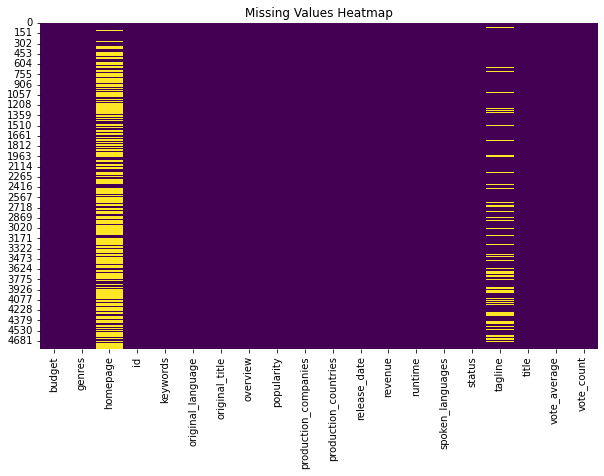

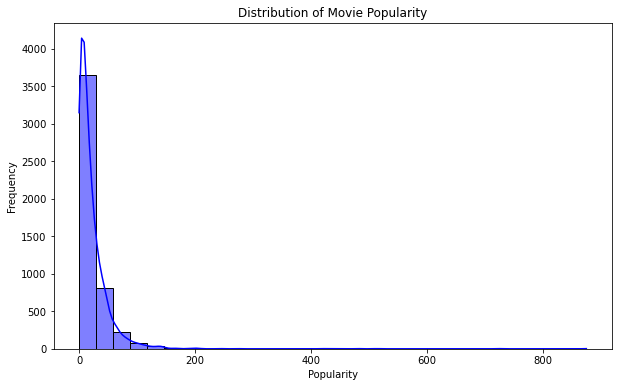

In [30]:
# Step 1: Exploratory Data Analysis (EDA)
def eda_and_visualizations(df):
    # Basic info
    print(df.info())
    print(df.describe())

    # Null values visualization
    plt.figure(figsize=(10, 6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.show()

    # Distribution of movie popularity
    plt.figure(figsize=(10, 6))
    sns.histplot(df['popularity'], bins=30, kde=True, color='blue')
    plt.title('Distribution of Movie Popularity')
    plt.xlabel('Popularity')
    plt.ylabel('Frequency')
    plt.show()

eda_and_visualizations(df)



In [31]:
nltk.download('all')
nltk.download('punkt_tab')
# Step 2: Preprocessing
def preprocess_data(df):
    # Tokenization and stopword removal
    stop_words = set(stopwords.words('english'))

    def clean_text(text):
        if isinstance(text, str):
            tokens = word_tokenize(text.lower())
            filtered_tokens = [word for word in tokens if word.isalnum() and word not in stop_words]
            return " ".join(filtered_tokens)
        return ""

    # Combine relevant text features into a single string (e.g., title, overview, genres)
    df['combined_features'] = df['title'] + " " + df['overview']
    df['combined_features'] = df['combined_features'].fillna('')  # Handle missing values
    df['combined_features'] = df['combined_features'].apply(clean_text)
    return df

df = preprocess_data(df)



[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_

[nltk_data]    |   Package maxent_treebank_pos_tagger_tab is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package mock_corpus to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Package mock_corpus is already up-to-date!
[nltk_data]    | Downloading package moses_sample to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Package moses_sample is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Package movie_reviews is already up-to-date!
[nltk_data]    | Downloading package mte_teip5 to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Package mte_teip5 is already up-to-date!
[nltk_data]    | Downloading package mwa_ppdb to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Package mwa_ppdb is already up-to-date!
[nltk_data

[nltk_data]    |   Package timit is already up-to-date!
[nltk_data]    | Downloading package toolbox to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Package toolbox is already up-to-date!
[nltk_data]    | Downloading package treebank to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Package treebank is already up-to-date!
[nltk_data]    | Downloading package twitter_samples to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Package twitter_samples is already up-to-date!
[nltk_data]    | Downloading package udhr to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Package udhr is already up-to-date!
[nltk_data]    | Downloading package udhr2 to
[nltk_data]    |     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]    |   Package udhr2 is already up-to-date!
[nltk_data]    | Downloading package unicode_samples to
[nltk_data]    |     C:\Users\

In [32]:
# Step 3: Feature Extraction (TF-IDF)
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['combined_features'])

# Step 4: Compute Similarities
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)



In [33]:
# Save the cosine similarity matrix and movie titles into a pickle file
import pickle

data_to_save = {
    'cosine_sim': cosine_sim,
    'movie_titles': df['title'].tolist()
}

with open("recommender.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

print("Pickle file 'recommender.pkl' has been created.")


Pickle file 'recommender.pkl' has been created.


In [34]:
# Step 5: Recommendation Function
def recommend_movies(title, df, cosine_sim):
    # Get the index of the movie that matches the title
    indices = pd.Series(df.index, index=df['title']).drop_duplicates()
    idx = indices.get(title, None)

    if idx is None:
        return f"Movie '{title}' not found in the dataset."

    # Get pairwise similarity scores for the movie
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the movies by similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the indices of the top 10 similar movies (excluding itself)
    sim_scores = sim_scores[1:11]

    # Get movie titles
    movie_indices = [i[0] for i in sim_scores]
    return df['title'].iloc[movie_indices]

# Test the recommendation system
movie_title = "The Dark Knight"
recommendations = recommend_movies(movie_title, df, cosine_sim)
print(f"Movies similar to '{movie_title}':")
print(recommendations)



Movies similar to 'The Dark Knight':
3                         The Dark Knight Rises
1359                                     Batman
3854    Batman: The Dark Knight Returns, Part 2
299                              Batman Forever
428                              Batman Returns
119                               Batman Begins
9            Batman v Superman: Dawn of Justice
210                              Batman & Robin
1181                                        JFK
4267                                     Batman
Name: title, dtype: object


In [35]:
# Metric evaluation
import pandas as pd
import numpy as np
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load datasets
movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

# Merge
credits.columns = ['id', 'title_temp', 'cast', 'crew']
df = movies.merge(credits, on='id')

# Parse genres
def extract_genres_column(genres_str):
    try:
        genres = ast.literal_eval(genres_str)
        return [g['name'] for g in genres]
    except:
        return []

df['parsed_genres'] = df['genres'].apply(extract_genres_column)

# Fill NaNs in overview
df['overview'] = df['overview'].fillna('')

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df['overview'])

# Cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Evaluation helpers
def genre_set(index):
    return set(df.iloc[index]['parsed_genres'])

def average_precision(recommended, relevant):
    hits = 0
    sum_precisions = 0
    for i, rec in enumerate(recommended):
        if rec in relevant:
            hits += 1
            sum_precisions += hits / (i + 1)
    return sum_precisions / len(relevant) if relevant else 0

def mean_reciprocal_rank(recommended_lists, relevant_lists):
    rr_total = 0
    for recommended, relevant in zip(recommended_lists, relevant_lists):
        for i, rec in enumerate(recommended):
            if rec in relevant:
                rr_total += 1 / (i + 1)
                break
    return rr_total / len(recommended_lists)

# Evaluation for multiple movies
query_movies = [
    "The Dark Knight Rises", "Avatar", "The Avengers", "The Godfather",
    "Inception", "Interstellar", "Toy Story", "The Lion King", "Titanic", "Jurassic Park"
]

top_k = 10
precision_scores = []
recall_scores = []
f1_scores = []
average_precisions = []
recommended_lists = []
relevant_lists = []
results_summary = []

for title in query_movies:
    if title not in df['title'].values:
        continue

    movie_index = df[df['title'] == title].index[0]
    sim_scores = list(enumerate(cosine_sim[movie_index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    top_k_indices = [i[0] for i in sim_scores[1:top_k+1]]

    target_genres = set(df.iloc[movie_index]['parsed_genres'])
    relevant_items = [i for i in df.index if i != movie_index and target_genres & set(df.iloc[i]['parsed_genres'])]

    recommended_set = set(top_k_indices)
    relevant_set = set(relevant_items)
    true_positives = recommended_set & relevant_set

    precision = len(true_positives) / top_k
    recall = len(true_positives) / len(relevant_set) if relevant_set else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    ap = average_precision(top_k_indices, relevant_items)
    average_precisions.append(ap)
    recommended_lists.append(top_k_indices)
    relevant_lists.append(relevant_items)

    results_summary.append({
        "Movie": title,
        "True Positives": len(true_positives),
        "Relevant Items": len(relevant_set),
        "Precision@10": round(precision, 4),
        "Recall@10": round(recall, 4),
        "F1-Score@10": round(f1, 4),
        "MAP": round(ap, 4),
        "MRR": round(mean_reciprocal_rank([top_k_indices], [relevant_items]), 4)
    })

# Final aggregate
overall_metrics = {
    "Mean Precision@10": round(np.mean(precision_scores), 4),
    "Mean Recall@10": round(np.mean(recall_scores), 4),
    "Mean F1-Score@10": round(np.mean(f1_scores), 4),
    "Mean MAP": round(np.mean(average_precisions), 4),
    "Mean MRR": round(mean_reciprocal_rank(recommended_lists, relevant_lists), 4)
}

# Display Results
df_results = pd.DataFrame(results_summary)
print(df_results)
print("\nOverall Metrics:\n", overall_metrics)


                   Movie  True Positives  Relevant Items  Precision@10  \
0  The Dark Knight Rises              10            3517           1.0   
1                 Avatar               8            1829           0.8   
2           The Avengers               8            1679           0.8   
3          The Godfather               6            2611           0.6   
4              Inception               8            2378           0.8   
5           Interstellar               9            3145           0.9   
6              Toy Story               7            1960           0.7   
7          The Lion King               6            2720           0.6   
8                Titanic               7            3283           0.7   
9          Jurassic Park               6            1119           0.6   

   Recall@10  F1-Score@10     MAP  MRR  
0     0.0028       0.0057  0.0028  1.0  
1     0.0044       0.0087  0.0035  1.0  
2     0.0048       0.0095  0.0043  1.0  
3     0.0023       0.